In [1]:
from core_functions import *
import auxilary_functions as aux
import pickle
import math
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib import gridspec
import numpy as np

In [2]:
with open('Orbits.pickle', 'rb') as handle:
    orbits = pickle.load(handle)

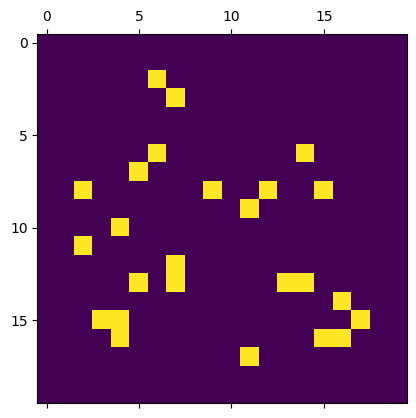

In [14]:
# Generate random uniform particle distribution and find where each orbit appears within

image = aux.unif_random_config(0.1, 25)
image = np.pad(image, ((2, 2), (2, 2)), 'constant', constant_values=((0, 0), (0, 0)))

y, x = image.shape

geo_found = []

for kernels in orbits:
    particle_no = kernels[0].sum()

    found_mat = np.zeros((y, x))

    orb = []

    for kernel in kernels:
        f = aux.find_geometry(image, kernel, particle_no=particle_no)
        orb.append(f)
    geo_found.append(orb)

fig, ax = plt.subplots(1, 1)

ax.matshow(image)

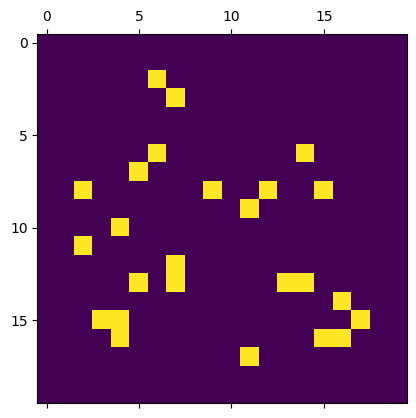

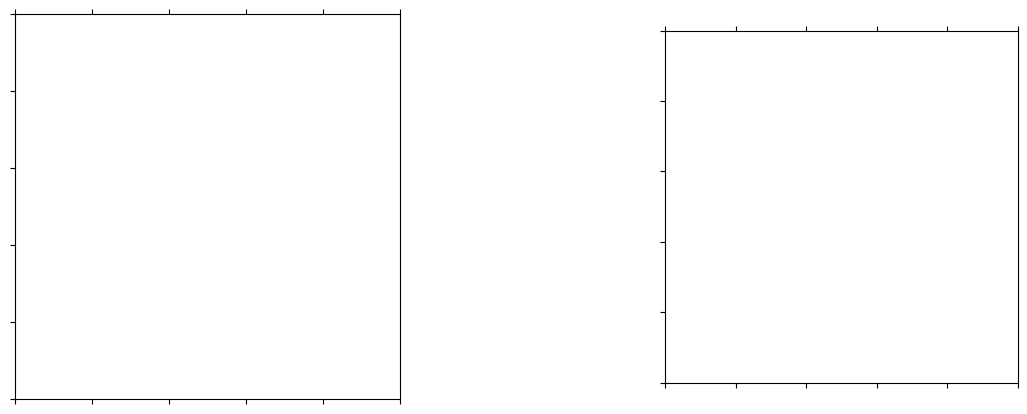

In [16]:
#CONVOLUTION ANIMATION


from matplotlib.animation import PillowWriter
metadata = dict(title='Movie', artist='codinglikemad')
writer = PillowWriter(fps=16, metadata=metadata)

#with writer.saving(fig, f'CONSTRUCTED_unif_ramsey_fringes.gif', 100):
fig, ax = plt.subplots(1, 1)

ax.matshow(image)

fig = plt.figure(figsize=(15, 5))
spec = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[2, 1])
convax = fig.add_subplot(spec[0])
configax = fig.add_subplot(spec[1])
temp_img = image.copy()

with writer.saving(fig, f'Convolution.gif', 100):
    count = 0
    for i, m in zip(orbits, geo_found):

        # Formatting
        convax.xaxis.set_tick_params(labelbottom=False)
        convax.yaxis.set_tick_params(labelleft=False)
        convax.set_xticks([])
        convax.set_yticks([])
        configax.xaxis.set_tick_params(labelbottom=False)
        configax.yaxis.set_tick_params(labelleft=False)
        configax.set_xticks([])
        configax.set_yticks([])

        # Present the configuration and its found instances in the larger distribution
        config = i[-1]
        colorbar = configax.matshow(config)
        colorbar.set_clim(0, 1)
        comap = convax.matshow(temp_img, cmap='gist_ncar')
        comap.set_clim(0, 1)
        
        
        writer.grab_frame()
        comp_img = temp_img.copy()

        # Changing color in large distribution where the configuration appears
        yes = 0
        for o, p in zip(i, m):
            non_zero = np.nonzero(p)

            ty, tx = o.shape
            if ty == 3 and tx == 5:
                for uy, ux in np.transpose(non_zero):
                    temp_img[uy - 1:uy + ty - 1, ux - 2:ux + tx - 2] -= np.rot90(o, k=2)/4
                    yes = 1
            elif ty == 5 and tx == 3:
                for uy, ux in np.transpose(non_zero):
                    temp_img[uy - 2:uy + ty - 2, ux - 1:ux + tx - 1] -= np.rot90(o, k=2)/4
                    yes = 1
            elif ty == 3 and tx == 4:
                for uy, ux in np.transpose(non_zero):
                    temp_img[uy - 1:uy + ty - 1, ux - 2:ux + tx - 2] -= np.rot90(o, k=2)/4
                    yes = 1
            elif ty == 4 and tx == 3:
                for uy, ux in np.transpose(non_zero):
                    temp_img[uy - 2:uy + ty - 2, ux - 1:ux + tx - 1] -= np.rot90(o, k=2)/4
                    yes = 1

            
            else:
                for uy, ux in np.transpose(non_zero):
                    temp_img[uy - 2:uy + ty - 2, ux - 2:ux + tx - 2] -= np.rot90(o, k=2)/4
                    yes = 1
                    
            
        if yes == 1:
            configax.clear()
            colorbar = configax.matshow(config/2)
            colorbar.set_clim(0, 1)
            for i in range(20):
                writer.grab_frame()
            convax.clear()
            convax.xaxis.set_tick_params(labelbottom=False)
            convax.yaxis.set_tick_params(labelleft=False)
            convax.set_xticks([])
            convax.set_yticks([])
            comap = convax.matshow(temp_img, cmap='gist_ncar')
            comap.set_clim(0, 1)
            for i in range(20):
                writer.grab_frame()
            count += 1
        else:
            writer.grab_frame()
        
        convax.clear()
        configax.clear()
# print(temp_img)